# Import library

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import matplotlib.pyplot as plt

# Read Data

In [ ]:
path = r'outputs\eda_all_plants_merged.csv'
df = pd.read_csv(path)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(['DATE_TIME', 'PLANT_NO']).reset_index(drop=True)


(6417, 39)
   PLANT_ID  PLANT_NO           DATE_TIME  DC_POWER_TOTAL  AC_POWER_TOTAL  \
0   4135001         1 2020-05-15 00:00:00             0.0             0.0   
1   4136001         2 2020-05-15 00:00:00             0.0             0.0   
2   4135001         1 2020-05-15 00:15:00             0.0             0.0   
3   4136001         2 2020-05-15 00:15:00             0.0             0.0   
4   4135001         1 2020-05-15 00:30:00             0.0             0.0   

   DAILY_YIELD_TOTAL  TOTAL_YIELD_TOTAL  ACTIVE_SOURCE_COUNT  ZERO_AC_COUNT  \
0           0.000000       1.435817e+08                   21             21   
1       48899.938095       1.418960e+10                   22             22   
2           0.000000       1.435817e+08                   21             21   
3       28401.000000       1.418960e+10                   22             22   
4           0.000000       1.435817e+08                   21             21   

   ZERO_AC_RATIO  ... HOUR  MINUTE  DAY  DAYOFWEEK 

In [4]:
df.head(10)

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO,...,HOUR,MINUTE,DAY,DAYOFWEEK,WEEKOFYEAR,MONTH,DAYOFYEAR,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,0,0,15,4,20,5,136,0.000000,1.000000,0
1,4136001,2,2020-05-15 00:00:00,0.0,0.0,48899.938095,1.418960e+10,22,22,1.0,...,0,0,15,4,20,5,136,0.000000,1.000000,0
2,4135001,1,2020-05-15 00:15:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,0,15,15,4,20,5,136,0.065403,0.997859,0
3,4136001,2,2020-05-15 00:15:00,0.0,0.0,28401.000000,1.418960e+10,22,22,1.0,...,0,15,15,4,20,5,136,0.065403,0.997859,0
4,4135001,1,2020-05-15 00:30:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,0,30,15,4,20,5,136,0.130526,0.991445,0
5,4136001,2,2020-05-15 00:30:00,0.0,0.0,28401.000000,1.418960e+10,22,22,1.0,...,0,30,15,4,20,5,136,0.130526,0.991445,0
6,4135001,1,2020-05-15 00:45:00,0.0,0.0,0.000000,1.435817e+08,21,21,1.0,...,0,45,15,4,20,5,136,0.195090,0.980785,0
7,4136001,2,2020-05-15 00:45:00,0.0,0.0,28401.000000,1.418960e+10,22,22,1.0,...,0,45,15,4,20,5,136,0.195090,0.980785,0
8,4135001,1,2020-05-15 01:00:00,0.0,0.0,0.000000,1.507616e+08,22,22,1.0,...,1,0,15,4,20,5,136,0.258819,0.965926,0
9,4136001,2,2020-05-15 01:00:00,0.0,0.0,26516.000000,1.418960e+10,22,22,1.0,...,1,0,15,4,20,5,136,0.258819,0.965926,0


In [5]:
print(df.shape)
print(df.info())

(6417, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6417 entries, 0 to 6416
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   PLANT_ID                     6417 non-null   int64         
 1   PLANT_NO                     6417 non-null   int64         
 2   DATE_TIME                    6417 non-null   datetime64[ns]
 3   DC_POWER_TOTAL               6417 non-null   float64       
 4   AC_POWER_TOTAL               6417 non-null   float64       
 5   DAILY_YIELD_TOTAL            6417 non-null   float64       
 6   TOTAL_YIELD_TOTAL            6417 non-null   float64       
 7   ACTIVE_SOURCE_COUNT          6417 non-null   int64         
 8   ZERO_AC_COUNT                6417 non-null   int64         
 9   ZERO_AC_RATIO                6417 non-null   float64       
 10  WEATHER_SENSOR_KEY           6416 non-null   object        
 11  AMBIENT_TEMPERATURE          641

# Visualization

## Check mising value

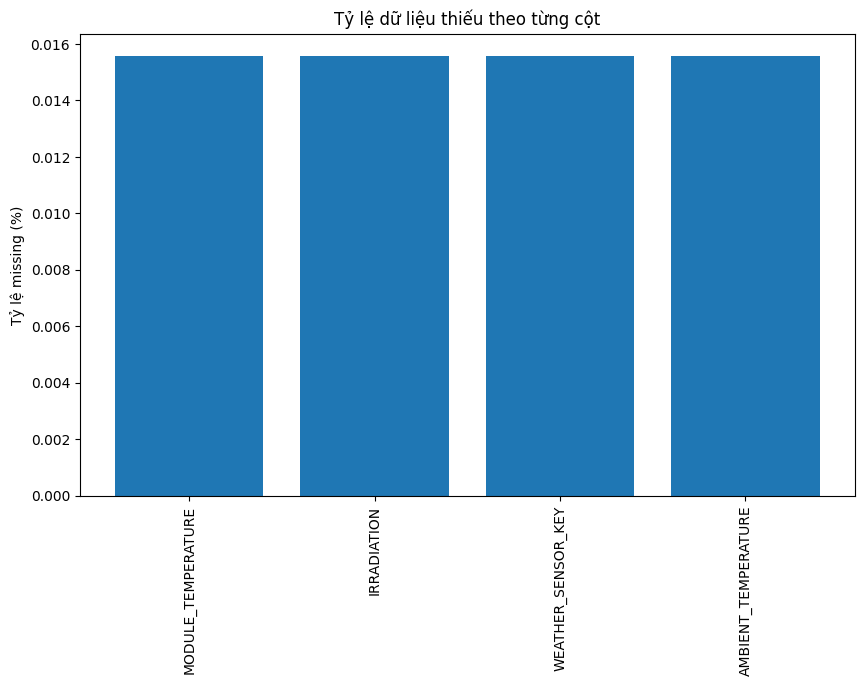

In [6]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(10, 6))
    plt.bar(missing.index, missing.values)
    plt.xticks(rotation=90)
    plt.ylabel('Tỷ lệ missing (%)')
    plt.title('Tỷ lệ dữ liệu thiếu theo từng cột')
    plt.show()
else:
    print("Không có dữ liệu thiếu nào trong DataFrame.")

## Visualization AC Power

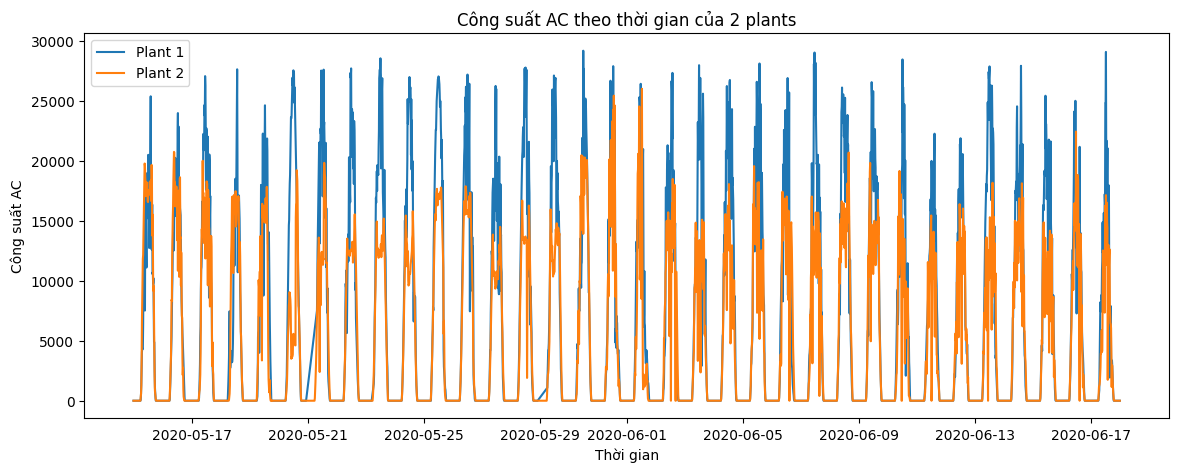

In [7]:
plt.figure(figsize=(14,5))
for plant  in df['PLANT_NO'].unique():
    temp = df[df['PLANT_NO'] == plant]
    plt.plot(temp['DATE_TIME'], temp['AC_POWER_TOTAL'],label=f'Plant {plant}')

plt.xlabel('Thời gian')
plt.ylabel('Công suất AC')
plt.title('Công suất AC theo thời gian của 2 plants')
plt.legend()
plt.show()

## Relationship between Irradiation and AC POWER

In [8]:
df.columns

Index(['PLANT_ID', 'PLANT_NO', 'DATE_TIME', 'DC_POWER_TOTAL', 'AC_POWER_TOTAL',
       'DAILY_YIELD_TOTAL', 'TOTAL_YIELD_TOTAL', 'ACTIVE_SOURCE_COUNT',
       'ZERO_AC_COUNT', 'ZERO_AC_RATIO', 'WEATHER_SENSOR_KEY',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
       'OM_TEMPERATURE_2M', 'OM_RELATIVE_HUMIDITY_2M', 'OM_DEW_POINT_2M',
       'OM_APPARENT_TEMPERATURE', 'OM_PRESSURE_MSL', 'OM_SURFACE_PRESSURE',
       'OM_PRECIPITATION', 'OM_CLOUD_COVER', 'OM_WIND_SPEED_10M',
       'OM_WIND_DIRECTION_10M', 'OM_SHORTWAVE_RADIATION',
       'OM_DIRECT_RADIATION', 'OM_DIFFUSE_RADIATION',
       'OM_DIRECT_NORMAL_IRRADIANCE', 'OM_SUNSHINE_DURATION', 'HOUR', 'MINUTE',
       'DAY', 'DAYOFWEEK', 'WEEKOFYEAR', 'MONTH', 'DAYOFYEAR', 'HOUR_SIN',
       'HOUR_COS', 'IS_DAYLIGHT'],
      dtype='object')

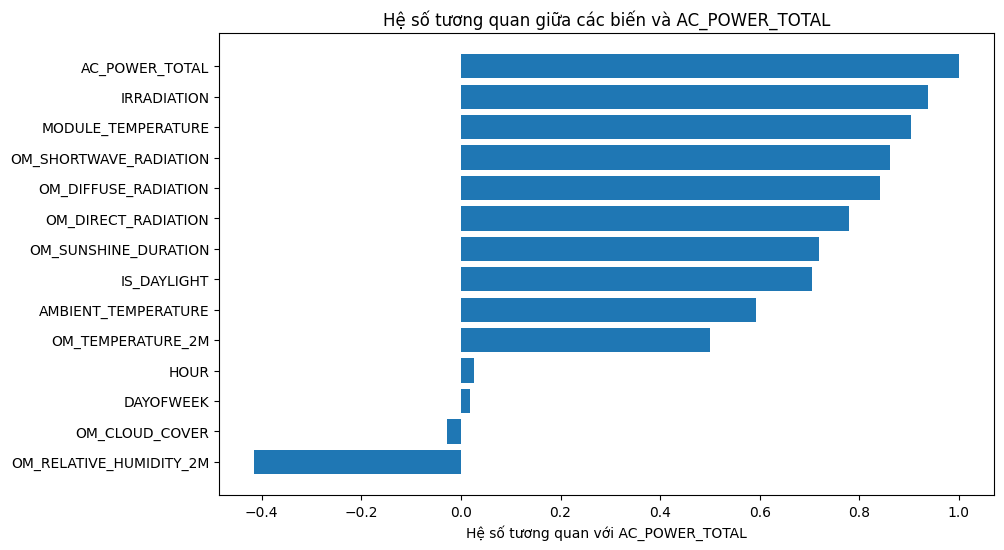

In [10]:
target = 'AC_POWER_TOTAL'

corr_col = [
    "AC_POWER_TOTAL",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION",
    "OM_TEMPERATURE_2M",
    'OM_RELATIVE_HUMIDITY_2M',
    'OM_CLOUD_COVER',
    'OM_SHORTWAVE_RADIATION',
    'OM_DIRECT_RADIATION',
    'OM_DIFFUSE_RADIATION',
    'OM_SUNSHINE_DURATION',
    'HOUR','DAYOFWEEK', 'DAYOFWEEK', 'IS_DAYLIGHT'


]

corr_col = [col for col in corr_col if col in df.columns]
corr = df[corr_col].corr()[target].sort_values()
plt.figure(figsize=(10, 6))
plt.barh(corr.index, corr.values)
plt.xlabel('Hệ số tương quan với AC_POWER_TOTAL')
plt.title('Hệ số tương quan giữa các biến và AC_POWER_TOTAL')
plt.show()

# Data Preprocessing

## Choose the Target and Feattures

In [11]:
df.columns

Index(['PLANT_ID', 'PLANT_NO', 'DATE_TIME', 'DC_POWER_TOTAL', 'AC_POWER_TOTAL',
       'DAILY_YIELD_TOTAL', 'TOTAL_YIELD_TOTAL', 'ACTIVE_SOURCE_COUNT',
       'ZERO_AC_COUNT', 'ZERO_AC_RATIO', 'WEATHER_SENSOR_KEY',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
       'OM_TEMPERATURE_2M', 'OM_RELATIVE_HUMIDITY_2M', 'OM_DEW_POINT_2M',
       'OM_APPARENT_TEMPERATURE', 'OM_PRESSURE_MSL', 'OM_SURFACE_PRESSURE',
       'OM_PRECIPITATION', 'OM_CLOUD_COVER', 'OM_WIND_SPEED_10M',
       'OM_WIND_DIRECTION_10M', 'OM_SHORTWAVE_RADIATION',
       'OM_DIRECT_RADIATION', 'OM_DIFFUSE_RADIATION',
       'OM_DIRECT_NORMAL_IRRADIANCE', 'OM_SUNSHINE_DURATION', 'HOUR', 'MINUTE',
       'DAY', 'DAYOFWEEK', 'WEEKOFYEAR', 'MONTH', 'DAYOFYEAR', 'HOUR_SIN',
       'HOUR_COS', 'IS_DAYLIGHT'],
      dtype='object')

In [ ]:
target = 'AC_POWER_TOTAL'
drop_cols =[
    'DATE_TIME',
    'PLANT_NO',
    'DC_POWER_TOTAL', 
    'AC_POWER_TOTAL',
    'DAILY_YIELD_TOTAL',
    'TOTAL_YIELD_TOTAL', 
    'ACTIVE_SOURCE_COUNT',
    'ZERO_AC_COUNT',
    'ZERO_AC_RATIO', 
    'WEATHER_SENSOR_KEY',

]

drop = [col for col in drop_cols if col in df.columns]
X = df.drop(columns=drop)
y= df[target]

print('Số features ban đầu:', X.shape[1])
print((X.columns))

Số features ban đầu: 29
Index(['PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
       'OM_TEMPERATURE_2M', 'OM_RELATIVE_HUMIDITY_2M', 'OM_DEW_POINT_2M',
       'OM_APPARENT_TEMPERATURE', 'OM_PRESSURE_MSL', 'OM_SURFACE_PRESSURE',
       'OM_PRECIPITATION', 'OM_CLOUD_COVER', 'OM_WIND_SPEED_10M',
       'OM_WIND_DIRECTION_10M', 'OM_SHORTWAVE_RADIATION',
       'OM_DIRECT_RADIATION', 'OM_DIFFUSE_RADIATION',
       'OM_DIRECT_NORMAL_IRRADIANCE', 'OM_SUNSHINE_DURATION', 'HOUR', 'MINUTE',
       'DAY', 'DAYOFWEEK', 'WEEKOFYEAR', 'MONTH', 'DAYOFYEAR', 'HOUR_SIN',
       'HOUR_COS', 'IS_DAYLIGHT'],
      dtype='object')


## One_hot encoding for PLANT_NO